The code and results in this notebook are under a CC-BY 4.0 license.

```
CC-BY TU Dresden

This notebook and its resulting graphics are licensed under a
Creative Commons Attribution 4.0 International License.

See <https://creativecommons.org/licenses/by/4.0/>.
```

In [1]:
%load_ext jupyter_tikz

preamble = r"""
\usepackage{hyperref}
\usepackage[T1]{fontenc}
\usepackage{fontawesome5}
\usepackage{ifthen}
\usepackage{mathabx}

\usepackage{tikz}

\usetikzlibrary{
  arrows.meta,
  calc,
  colorbrewer,
  fadings,
  fit,
  positioning,
}
\pgfdeclarelayer{bg}    % declare background layer
\pgfdeclarelayer{fg}    % declare foreground layer
\pgfsetlayers{bg,main,fg}  % set the order of the layers (main is the standard layer)

\tikzset{
  collection-color/.style = {
    fill = Pastel2-A,
  },
  generation-color/.style = {
    fill = Pastel2-C,
  },
  analysis-color/.style = {
    fill = Pastel2-B,
  },
  node/.style = {
    rectangle,
    align = center,
    draw = none,
    fill = white,
    line width = 1pt,
    rounded corners = 3pt,
    node distance = 7mm and 15mm,
    font=\scriptsize,
  },
  method-step/.style = {
    rectangle,
    draw = none,
    rounded corners = 5pt,
    inner sep = 5pt,
  },
  collection/.style = {
    method-step,
    collection-color,
  },
  generation/.style = {
    method-step,
    generation-color,
  },
  analysis/.style = {
    method-step,
    analysis-color,
    inner xsep = 2pt,
  },
  result/.style = {
    -stealth,
    line width=1pt,
    rounded corners=0.5em,
  },
  bare-result-text/.style = {
    % fill=white,
    fill opacity=0.90,
    inner xsep=0.5pt,
    inner ysep=0.5pt,
    draw=none,
    align=center,
    rounded corners=0.1em,
    font=\scriptsize,
  },
  result-text/.style = {
    bare-result-text,
    pos=0.5,
  },
  collection-result-text/.style = {
    result-text,
    % collection-color,
  },
  generation-result-text/.style = {
    result-text,
    % generation-color,
  },
  analysis-result-text/.style = {
    result-text,
    % analysis-color,
  },
  file/.style = {
    rectangle,
    draw=black,
    outer sep=0,
  },
}

\newcommand{\file}[6][]{
  \begin{scope}[shift={#3}, #1]
    \begin{scope}[x=1.7pt, y=1.7pt]
      \draw [draw=none, fill={#4-J}] (1, 7) -- ++(4, -4) -- ++(0, -9) arc (0:-90:1) -- ++(-8, 0) arc (270:180:1) -- ++(0, 12) arc (180:90:1);
      \begin{scope}
        \clip ($(2, 4)+(225:1)$) -- (5, -0.8) -- (5, 3) -- cycle;
        \node [rectangle, fill={#4-M!50!black}, draw=none, postaction={path fading=north, fading angle=45, fill={#4-J}}, anchor=north west, inner sep=0, outer sep=0, minimum width=8.0pt, minimum height=9.6pt] at (1, 4) {};
      \end{scope}
      \draw [draw=none, fill={#4-M}] (1, 7) -- ++(0, -3) arc (180:270:1) -- ++(3, 0) -- cycle;
      \draw [draw=none, fill={#4-M}] (5, -3.5) -- ++(0, -2.5) arc (0:-90:1) -- ++(-8, 0) arc (270:180:1) -- ++(0, 2.5) -- cycle;
      \node [color=white, font=\sffamily\bfseries\tiny] at (0, -5.25) {#5};
      \ifthenelse{\equal{#6}{}}{}{
        \node [color=white, font=\small] at (0, 0) {#6};
      }
    \end{scope}
  \end{scope}
  \node [file, inner sep=0, minimum width=20pt, minimum height=28pt, draw=none, fill=none] (#2) at #3 {};
}

\newcommand{\files}[6][]{
  \foreach \i in {2, 1, 0} {
    \file [#1, fill opacity=1.0-(0.4*\i)]  {#2 \i}{($#3 + (-0.06 * \i, 0.06 * \i)$)}{#4}{#5}{#6}
  }
  \file[#1]{#2}{#3}{#4}{#5}{#6}
}

\hypersetup{
  linkcolor=black,
}
"""

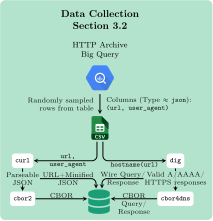

In [2]:
%%tikz -p "$preamble" -S 03_2_data_collection/method

\begin{tikzpicture}
  \begin{scope}
    \node [label={[name=Big Query Label,align=center, font=\footnotesize]above:{HTTP Archive\\Big Query}}] (Big Query) {\includegraphics[width=1cm]{bigquery-logo}};

    \coordinate [below=12mm of Big Query] (Big Query CSV coordinate);
    \file {Big Query CSV}{(Big Query CSV coordinate)}{Greens}{CSV}{\faIcon{table}}

    \node [node, below left=4mm and 20mm of Big Query CSV] (curl) {\ttfamily curl\strut};
    \node [node, below right=4mm and 20mm of Big Query CSV] (dig) {\ttfamily dig\strut};
    \node [node, below=8mm of curl] (cbor) {\ttfamily cbor2\strut};
    \node [node, below=8mm of dig] (cbor4dns) {\ttfamily cbor4dns\strut};

    \node [color=Dark2-A, inner sep=0, outer sep=1pt] (DB) at ($(cbor.center)!0.5!(cbor4dns.center) - (0, 3pt)$) {\Huge \faIcon{database}};

    \draw [result] (Big Query) -- (Big Query CSV) node [midway, coordinate] (SQL coordinate) {};
    \node [bare-result-text, anchor=west, align=left, xshift=2mm] (SQL) at (SQL coordinate) {%
      % \ttfamily\ 2024\_09\_01\_desktop(\\
      Columns (Type $\approx$ \texttt{json}):\\
      \ttfamily (url, user\_agent)
    };
    \node [bare-result-text, anchor=east, align=right, xshift=-2mm] (SQL Sample) at (SQL coordinate) {%
        Randomly sampled\\rows from table
    };
    \draw [result] ([xshift=-3pt]Big Query CSV.south) |- (curl) node [collection-result-text, pos=.73] {\ttfamily url,\\\ttfamily user\_agent};
    \draw [result] ([xshift=3pt]Big Query CSV.south) |- (dig) node [collection-result-text, pos=.75, below] {\ttfamily hostname(url)};
    \draw [result] (curl) -- (cbor) node [collection-result-text, collection-color, pos=0.45] (Parseable JSON) {Parseable\\JSON};
    \draw [result] (dig) -- (cbor4dns) node [collection-result-text, collection-color, pos=0.45] (DNS records) {Valid A/AAAA/\\HTTPS responses};
    \draw [result] (DNS records) -| ([xshift=3pt]DB.north) node [collection-result-text, pos=.25] {Wire Query/\\Response};
    \draw [result] (Parseable JSON) -| ([xshift=-3pt]DB.north) node [collection-result-text, pos=.25] {URL+Minified\\JSON};
    \draw [result] (cbor.east) -- (cbor.east -| DB.west) node [collection-result-text, above] {CBOR};
    \draw [result] (cbor4dns.west) -- (cbor4dns.west -| DB.east) node [collection-result-text, yshift=-.54em] {CBOR\\Query/\\Response};

    \node [above=0.25em of Big Query Label, align=center, font=\normalsize\bfseries] (Data Collection Title) {Data Collection\strut\\Section~3.2\strut};

    \begin{pgfonlayer}{bg}
      \node [collection, fit={(Data Collection Title) (Parseable JSON) (DNS records) (cbor) (cbor4dns) (DB)}] (Data Collection) {};
    \end{pgfonlayer}
  \end{scope}

\end{tikzpicture}

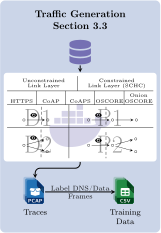

In [3]:
%%tikz -p "$preamble" -S 03_3_traffic_generation/method


\begin{tikzpicture}
  \begin{scope}[xshift=0]
    \node [font=\normalsize\bfseries, anchor=south, align=center] (Traffic Generation Title) {Traffic Generation\strut\\Section~3.3\strut};
    \node [color=Dark2-C, inner sep=0, outer sep=1pt, below=1mm of Traffic Generation Title] (DB) {\Huge \faIcon{database}};
    \begin{scope}[shift=(DB.south), anchor=north]
      \tikzset{
        node/.style = {
          circle,
          draw = black,
          line width = 1pt / 3,
          inner sep = 0,
          outer sep = 0,
          minimum width = 2.5mm / 3,
          node distance = 5mm / 3 and 23mm / 3,
        },
        msg/.style = {
          -{stealth},
          draw,
          line width = 1pt / 3,
          shorten >= 2mm / 3,
          shorten <= 2mm / 3,
        },
        msg-label/.style = {
          pos=.4,
          font=\footnotesize,
          scale=3/4,
          above,
        },
        scenario-label/.style = {
          font=\huge,
          opacity=.4,
          anchor=center,
        },
        protocol-label/.style = {
          font=\tiny,
          anchor=south,
          align=center,
          outer xsep=0,
          outer ysep=2pt,
          inner sep=0,
        },
      }
      \begin{scope}[xshift=-20mm, yshift=-19mm, scale=1/3]
        \node [node] (C) {};
        \node [node, right=of C] (S) {};

        \draw [msg] (C) -- (S) node [msg-label] (sniffer) {\faIcon{eye}};

        \draw [densely dashed] ($(sniffer.south east) + (0.5em, 4em)$) node [coordinate] (wireless border north) {} -- ($(sniffer.south east) + (0.5em, -2em)$) node [coordinate] (wireless border south) {};
      \end{scope}
      \begin{scope}[xshift=3mm, yshift=-19mm, scale=1/3]
        \node [node] (C) {};
        \node [node, right=of C] (P) {};
        \node [node, right=of P] (S) {};

        \draw [msg] (C) -- (P) node [msg-label] (sniffer) {\faIcon{eye}};
        \draw [msg] (P) -- (S);

        \draw [densely dashed] ($(sniffer.south east) + (0.5em, 4em)$) node [coordinate] (wireless border north) {} -- ($(sniffer.south east) + (0.5em, -2em)$) node [coordinate] (wireless border south) {};
      \end{scope}
      \begin{scope}[xshift=-20mm, yshift=-28mm, scale=1/3]
        \node [node] (C) {};
        \node [node, above right=of C] (NS) {};
        \node [node, below right=of C] (DS) {};

        \draw [msg] (C) -- (NS) node [msg-label] (sniffer) {\faIcon{eye}};
        \draw [densely dashed] ($(sniffer.south east) + (0.5em, 4em)$) node [coordinate] (wireless border north) {} -- ($(sniffer.south east |- DS) + (0.5em, -2em)$) node [coordinate] (wireless border south) {};
        \draw [msg] (C) -- (DS);
      \end{scope}
      \begin{scope}[xshift=3mm, yshift=-28mm, scale=1/3]
        \node [node] (C) {};
        \node [node, right=of C] (P) {};
        \node [node, above right=of P] (NS) {};
        \node [node, below right=of P] (DS) {};

        \draw [msg] (C) -- (P) node [msg-label] (sniffer) {\faIcon{eye}};
        \draw [msg] (P) -- (NS);
        \draw [msg] (P) -- (DS);

        \draw [densely dashed] ($(sniffer.south east) + (0.5em, 4em)$) node [coordinate] (wireless border north) {} -- ($(sniffer.south east |- DS) + (0.5em, -2em)$) node [coordinate] (wireless border south) {};
      \end{scope}

      \begin{scope}[yshift=-16mm]
        \draw (-26mm, -6mm) node [coordinate] (scenarios left) {} -- ++(52mm, 0) node [coordinate] (scenarios right) {};
        \draw (-4mm, 2mm) -- ++(0, -19mm) node [coordinate] (scenarios bottom) {};
        \draw (-26mm, 2mm) -- ++(52mm, 0);

        \node [scenario-label] at (-15mm, -2.5mm) {\Huge D1};
        \node [scenario-label] at (-15mm, -12mm) {\Huge D2};
        \node [scenario-label] at (10.5mm, -2.5mm) {\Huge P1};
        \node [scenario-label] at (10.5mm, -12mm) {\Huge P2};

        \draw (-26mm + 1 * 52mm / 5, 2mm) -- ++(0, 1.4em);
        \draw (-26mm + 2 * 52mm / 5, 2mm) -- ++(0, 1.4em);
        \draw (-26mm + 3 * 52mm / 5, 2mm) -- ++(0, 1.4em);
        \draw (-26mm + 4 * 52mm / 5, 2mm) -- ++(0, 1.4em);
        \draw (-26mm, 2mm + 1.4em) -- ++(52mm, 0);
        \draw (-26mm + 1 * 50mm / 2, 2mm + 1.4em) -- ++(0, 1.5em) node [coordinate] (scenarios top) {};

        \node [protocol-label] at (52mm / 10 - 26mm + 0 * 52mm / 5, 2mm) {HTTPS};
        \node [protocol-label] at (52mm / 10 - 26mm + 1 * 52mm / 5, 2mm) {CoAP};
        \node [protocol-label] at (52mm / 10 - 26mm + 2 * 52mm / 5, 2mm) {CoAPS};
        \node [protocol-label] at (52mm / 10 - 26mm + 3 * 52mm / 5, 2mm) {OSCORE};
        \node [protocol-label] at (52mm / 10 - 26mm + 4 * 52mm / 5, 2mm) {Onion\\OSCORE};

        \node [protocol-label] at (52mm / 4 - 26mm + 0 * 52mm / 2, 2mm + 1.4em) {Unconstrained\strut\\[-0.125em]Link Layer\strut};
        \node [protocol-label] at (52mm / 4 - 26mm + 1 * 52mm / 2, 2mm + 1.4em) {Constrained\strut\\[-0.125em]Link Layer (SCHC)\strut};
      \end{scope}
    \end{scope}


    \coordinate (scenarios center) at ($(scenarios left)!0.5!(scenarios right)$);
    \coordinate (scenarios south) at (scenarios bottom -| scenarios center);

    \coordinate [below=12mm of scenarios south, xshift=-16mm] (PCAPs coordinate);
    \files{PCAPs}{(PCAPs coordinate)}{Blues}{PCAP}{\faIcon{box-open}}
    \node [below=0em of PCAPs, font=\footnotesize, align=center] (PCAPs label) {Traces};

    \coordinate [below=12mm of scenarios south, xshift=16mm] (Training Data coordinate);
    \files{Training Data}{(Training Data coordinate)}{Greens}{CSV}{\faIcon{table}}
    \node [below=0em of Training Data, font=\footnotesize, align=center] (Training Data label) {Training\\Data};

    \draw [result] (PCAPs) -- (Training Data) node [generation-result-text] {Label DNS/Data\\Frames};
    \coordinate (generation bottom) at (scenarios south |- DB.south);

    \begin{pgfonlayer}{bg}
      \node [generation, inner xsep=7pt, fit={(Traffic Generation Title) (scenarios top) (scenarios bottom) (scenarios left) (scenarios right) (Training Data label) (PCAPs label) (generation bottom)}] (Traffic Generation) {};
      \node [node, fit={(scenarios top) (scenarios bottom) (scenarios left) (scenarios right)}] (scenarios) {};
      \node [color=Dark2-C, font=\Huge, opacity=.3, yshift=-3mm, scale=2] at (scenarios.center) {\faIcon{docker}};
    \end{pgfonlayer}

    \draw [result] (scenarios.south) |- ([yshift=1em]PCAPs.north) -- (PCAPs.north);

    \draw [result] (DB) -- (scenarios);
  \end{scope}
\end{tikzpicture}

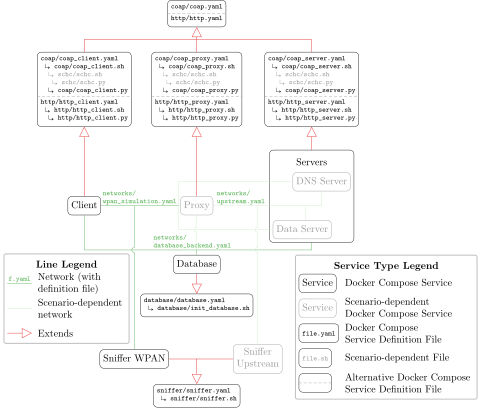

In [4]:
%%tikz -p "$preamble" -S 03_3_traffic_generation/docker-compose

\tikzset{
    service/.style = {
        rectangle,
        rounded corners,
        color=black,
        draw=black,
        fill=white,
        font=\strut,
        node distance=0.5em and 8em,
        anchor=center,
        align=center,
    },
    optional service/.style = {
        service,
        color=Set1-I,
        draw=Set1-I,
        fill=white,
    },
    service file/.style = {
        service,
        font=\strut\ttfamily\scriptsize,
        align=left,
    },
    network/.style = {
        draw=Set1-C,
    },
    optional network/.style = {
        draw=Pastel1-C,
    },
    jump/.style = {
        radius=0.25em,
    },
    vertical jump/.style = {
        jump,
        start angle=90,
        end angle=270,
    },
    vertical jump start/.style = {
        yshift=0.25em,
    },
    network label/.style = {
        above=0.1em,
        inner sep=0pt,
        outer sep=0pt,
        color=Set1-C,
        font=\ttfamily\scriptsize,
        align=left,
    },
    inheritance/.style = {
        draw=Set1-A,
        -{Stealth[inset=0pt, length=1em, width=1em, fill=white]},
    },
    legend/.style = {
        rectangle,
        fill=white,
        rounded corners=2pt,
        line width=1pt,
        draw=gray!50!white,
    },
    legend title/.style = {
        font=\bfseries,
    },
    legend handle blind/.style = {
        rectangle,
        rounded corners,
        draw=none,
        fill=none,
        inner sep=1pt,
        font=\strut\ttfamily\scriptsize\phantom{f.yaml},
        anchor=west,
    },
    legend label/.style = {
        align=left,
        anchor=west,
    },
}

\begin{tikzpicture}
\node [optional service] (Proxy) {Proxy};
\node [service, left=of Proxy] (Client) {Client};
\node [optional service, above right=of Proxy] (DNS Server) {DNS Server};
\node [optional service, below right=0.5em and 6em of Proxy] (Data Server) {Data Server};

\begin{pgfonlayer}{bg}
\node [service, draw=none, fill=none, above=0pt of DNS Server] (Server Placeholder) {\phantom{Server}};
\node [service, fit={(DNS Server) (Data Server) (Server Placeholder)}] (Servers) {};
\node [below=0.5em of Servers.north] {Servers};
\end{pgfonlayer}

\node [service file, above=7em of Proxy] (Proxy Files) {%
    coap/coap\_proxy.yaml\\
    \ $\drsh$ coap/coap\_proxy.sh\\
    \ \ \color{Set1-I} $\drsh$ schc/schc.sh\\
    \ \ \ \color{Set1-I} $\drsh$ schc/schc.py\\
    \ \ $\drsh$ coap/coap\_proxy.py\\[0.5em]
    http/http\_proxy.yaml\\
    \ $\drsh$ http/http\_proxy.sh\\
    \ \ $\drsh$ http/http\_proxy.py%
};
\draw [densely dashed, Set1-I] (Proxy Files.189) -- (Proxy Files.351);

\node [service file] (Client Files) at (Client |- Proxy Files) {%
    coap/coap\_client.yaml\\
    \ $\drsh$ coap/coap\_client.sh\\
    \ \ \color{Set1-I} $\drsh$ schc/schc.sh\\
    \ \ \ \color{Set1-I} $\drsh$ schc/schc.py\\
    \ \ $\drsh$ coap/coap\_client.py\\[0.5em]
    http/http\_client.yaml\\
    \ $\drsh$ http/http\_client.sh\\
    \ \ $\drsh$ http/http\_client.py%
};
\draw [densely dashed, Set1-I] (Client Files.189) -- (Client Files.351);

\node [service file] (Server Files) at (Servers |- Proxy Files) {%
    coap/coap\_server.yaml\\
    \ $\drsh$ coap/coap\_server.sh\\
    \ \ \color{Set1-I} $\drsh$ schc/schc.sh\\
    \ \ \ \color{Set1-I} $\drsh$ schc/schc.py\\
    \ \ $\drsh$ coap/coap\_server.py\\[0.5em]
    http/http\_server.yaml\\
    \ $\drsh$ http/http\_server.sh\\
    \ \ $\drsh$ http/http\_server.py%
};
\draw [densely dashed, Set1-I] (Server Files.189) -- (Server Files.351);

\node [service file, above=2.5em of Proxy Files] (Base Files) {%
    coap/coap.yaml\\[0.5em]
    http/http.yaml%
};
\draw [densely dashed, Set1-I] (Base Files.west) -- (Base Files.east);

\node [service, below=4em of Proxy] (Database) {Database};

\node [service file, below=2em of Database] (Database Files) {%
    database/database.yaml\\
    \ $\drsh$ database/init\_database.sh%
};

\node [optional service, below right=13em and 2em of Proxy] (Sniffer Upstream) {Sniffer\\Upstream};
\coordinate (Upstream Sniffer Measuring Point) at (Proxy.east -| Sniffer Upstream.north);
\coordinate (WPAN Sniffer Measuring Point) at ($(Client.east)!0.42!(Proxy.west)$);
\node [service] (Sniffer WPAN) at (Sniffer Upstream.west -| WPAN Sniffer Measuring Point) {Sniffer WPAN};

\node [service file, below=17em of Proxy] (Sniffer Files) {%
    sniffer/sniffer.yaml\\
    \ $\drsh$ sniffer/sniffer.sh%
};

\draw [optional network] ([xshift=-2pt]Proxy.west) |- (DNS Server);
\draw [optional network] ([xshift=-2pt]Proxy.west) |- (Data Server);
\draw [optional network] ([xshift=-2pt]Proxy.west) -- (Proxy);
\draw [network] (Client) -- ([xshift=-2pt]Proxy.west) node [midway, network label] {networks/\\wpan\_simulation.yaml};

\draw [optional network] (Proxy) -| (Data Server.70) node [pos=.15, network label] {networks/\\upstream.yaml};
\draw [optional network] (Proxy -| Data Server.70) -| (DNS Server);

\coordinate (Proxy Database Jump Point) at (Proxy.south |- Data Server.east);
\draw [optional network] (Proxy) -- ([vertical jump start]Proxy Database Jump Point) arc [vertical jump] -- ([yshift=0.5em]Database.north) node [coordinate] (Database Connection) {};
\draw [network] (Database Connection) -- (Database);
\draw [network] (Client) |- (Database Connection) node [pos=.98, network label] {networks/\\database\_backend.yaml};
\draw [network] (Servers) |- (Database Connection);

\draw [network] (WPAN Sniffer Measuring Point) --
    ([vertical jump start]WPAN Sniffer Measuring Point |- Database Connection) arc [vertical jump] --
    (Sniffer WPAN);
\draw [optional network] (Upstream Sniffer Measuring Point) --
    ([vertical jump start]Upstream Sniffer Measuring Point |- Data Server.west) arc [vertical jump] --
    ([vertical jump start]Upstream Sniffer Measuring Point |- Database Connection) arc [vertical jump] --
    (Sniffer Upstream);

\draw [inheritance] (Proxy) -- (Proxy Files);
\draw [inheritance] (Client) -- (Client Files);
\draw [inheritance] (Servers) -- (Server Files);
\coordinate (Proxy Base Files midpoint) at ($(Proxy Files.north)!0.5!(Base Files.south)$);
\draw [inheritance] (Proxy Files) -- (Base Files);
\draw [inheritance, -] (Client Files) |- (Proxy Base Files midpoint);
\draw [inheritance, -] (Server Files) |- (Proxy Base Files midpoint);

\draw [inheritance] (Database) -- (Database Files);

\draw [inheritance] (Sniffer WPAN) -| (Sniffer Files);
\draw [inheritance, -] (Sniffer Upstream) -- (Sniffer WPAN -| Sniffer Files);

\node [service, anchor=north west] at (Data Server.250 |- Database.south east) (Service legend handle) {Service};
\node [optional service, below=0.6em of Service legend handle.south west, anchor=north west] (Optional service legend handle) {Service};
\node [service file, below=0.6em of Optional service legend handle.south west, anchor=north west] (Service files legend handle) {file.yaml};
\node [service file, below=0.6em of Service files legend handle.south west, anchor=north west] (Optional service files legend handle) {\color{Set1-I}file.sh};
\node [service file, below=0.6em of Optional service files legend handle.south west, anchor=north west] (Alternative service files legend handle) {\phantom{Service}};
\draw [densely dashed, Set1-I] (Alternative service files legend handle.west) -- (Alternative service files legend handle.east);

\node [legend label] (Service legend label) at ([xshift=0.25em]Service legend handle.east -| Service files legend handle.east) {Docker Compose Service};
\node [legend label] (Optional service legend label) at (Optional service legend handle.east -| Service legend label.west) {Scenario-dependent\\Docker Compose Service};
\node [legend label] (Service files legend label) at (Service files legend handle.east -| Service legend label.west) {Docker Compose\\Service Definition File};
\node [legend label] (Optional service files legend label) at (Optional service files legend handle.east -| Service legend label.west) {Scenario-dependent File};
\node [legend label] (Alternative service files legend label) at (Alternative service files legend handle.east -| Service legend label.west) {Alternative Docker Compose\\Service Definition File};

\node [legend title] (Service legend title) at ([yshift=0.75em]$(Service legend handle.north west)!0.5!(Alternative service files legend label.east |- Service legend handle.north west)$)
    {Service Type Legend};
\begin{pgfonlayer}{bg}
\node [legend, fit={(Service legend title) (Service legend handle) (Alternative service files legend label)}] (Service legend) {};
\end{pgfonlayer}

\node [legend handle blind] (Network handle) at ([xshift=-3em]Client Files.west |- Service legend handle) {};
\draw [network] (Network handle.west) -- (Network handle.east) node [midway, network label] {f.yaml};
\node [legend handle blind] (Optional network handle) at (Network handle.west |- Optional service legend handle) {};
\draw [optional network] (Optional network handle.west) -- (Optional network handle.east);
\node [legend handle blind] (Inheritance handle) at (Network handle.west |- Service files legend handle) {};
\draw [inheritance] (Inheritance handle.west) -- (Inheritance handle.east);

\node [legend label] (Network label) at ([xshift=0.25em]Network handle.east) {Network (with\\definition file)};
\node [legend label] (Optional network label) at ([xshift=0.25em]Optional network handle.east) {Scenario-dependent\\network};
\node [legend label] (Inheritance label) at ([xshift=0.25em]Inheritance handle.east) {Extends};

\node [legend title] (Lines legend title) at ([yshift=0.75em]$(Network handle.north west |- Network label.north)!0.5!(Optional network label.east |- Network handle.north west)$)
    {Line Legend};
\begin{pgfonlayer}{bg}
\node [legend, fit={(Lines legend title) (Network handle) (Inheritance label) (Optional network label)}] (Service legend) {};
\end{pgfonlayer}

\end{tikzpicture}

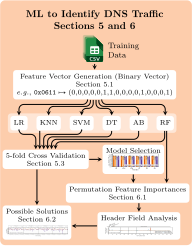

In [5]:
%%tikz -p "$preamble"

\begin{tikzpicture}
  \begin{scope}
    \node [font=\normalsize\bfseries, anchor=south, align=center] (Machine Learning Analysis Title) {ML to Identify DNS Traffic\strut\\Sections 5 and 6\strut};

    \coordinate [below=5mm of Machine Learning Analysis Title] (Training Data coordinate);
    \files{Training Data}{(Training Data coordinate)}{Greens}{CSV}{\faIcon{table}}
    \node [right=0em of Training Data, font=\footnotesize, align=left] (Training Data label) {Training\\Data};
        
    \node [node, below=2.0mm of Training Data.south] (Feature Vector Generation) {Feature Vector Generation (Binary Vector)\\Section 5.1\\\emph{e.g.}, $\mathtt{0x0611} \mapsto (0{,}0{,}0{,}0{,}0{,}1{,}1{,}0{,}0{,}0{,}0{,}1{,}0{,}0{,}0{,}1)$};
    \node [node, below=5.5mm of Feature Vector Generation.south, anchor=north east, xshift=-0.05em] (SVM) {SVM\strut};
    \node [node, below=5.5mm of Feature Vector Generation.south, anchor=north west, xshift=0.75em] (DT) {DT\strut};
    \node [node, left=0.8em of SVM.west, anchor=east] (KNN) {KNN\strut};
    \node [node, left=0.8em of KNN.west, anchor=east] (LR) {LR\strut};
    \node [node, right=0.8em of DT.east, anchor=west] (AB) {AB\strut};
    \node [node, right=0.8em of AB.east, anchor=west] (RF) {RF\strut};

    \node [node, below=6.5mm of SVM.south east, anchor=north east, xshift=-0.5em] (Cross Validation) {5-fold Cross Validation\\Section 5.3};
    \node [node, anchor=west] (Model Selection) at (DT.south west |- Cross Validation.center)  {Model Selection\\\includegraphics[width=18mm]{plots/classifier_metrics_base}};
    \node [node, below=3mm of Model Selection, xshift=-2mm] (Feature Importance) {Permutation Feature Importances\\Section 6.1};

    \node [node, below=3mm of Feature Importance, xshift=4mm] (Header Field Analysis) {Header Field Analysis\\\includegraphics[width=24mm]{plots/perm_imp_binvec_rf_d2_oscore_schc-peer-based_64}};

    \coordinate (Proposed Solutions coordinate) at (Cross Validation.south west |- Header Field Analysis.south);
    \node [node, anchor=south west] (Proposed Solutions) at (Proposed Solutions coordinate) {Possible Solutions\\Section 6.2\\[.4em]\includegraphics[width=22mm]{plots/blockwise_rf_accuracy}};

    \coordinate (analysis bottom) at (Header Field Analysis.south);

    \draw [result] ([xshift=-2.5mm]Feature Vector Generation.south) -- ([xshift=-2.5mm, yshift=-1.6mm]Feature Vector Generation.south) -| (LR);
    \draw [result] ([xshift=-1.5mm]Feature Vector Generation.south) -- ([xshift=-1.5mm, yshift=-2.3mm]Feature Vector Generation.south) -| (KNN);
    \draw [result] ([xshift=-0.5mm]Feature Vector Generation.south) -- ([xshift=-0.5mm, yshift=-3.0mm]Feature Vector Generation.south) -| (SVM);
    \draw [result] ([xshift=+0.5mm]Feature Vector Generation.south) -- ([xshift=+0.5mm, yshift=-3.0mm]Feature Vector Generation.south) -| (DT);
    \draw [result] ([xshift=+1.5mm]Feature Vector Generation.south) -- ([xshift=+1.5mm, yshift=-2.3mm]Feature Vector Generation.south) -| (AB);
    \draw [result] ([xshift=+2.5mm]Feature Vector Generation.south) -- ([xshift=+2.5mm, yshift=-1.6mm]Feature Vector Generation.south) -| (RF);

    \draw [result] (LR) |- ([xshift=-3.5mm, yshift=1.50em]Cross Validation.north) -- ([xshift=-3.5mm]Cross Validation.north);
    \draw [result, rounded corners=0.25em] ([xshift=-2.1mm]KNN.south -| Cross Validation.north) -- ([xshift=-2.1mm]Cross Validation.north);
    \draw [result] (SVM) |- ([xshift=-0.7mm, yshift=1.50em]Cross Validation.north) -- ([xshift=-0.7mm]Cross Validation.north);
    \draw [result] (DT) |- ([xshift=0.7mm, yshift=1.25em]Cross Validation.north) -- ([xshift=0.7mm]Cross Validation.north);
    \draw [result] (AB) |- ([xshift=2.1mm, yshift=1.00em]Cross Validation.north) -- ([xshift=2.1mm]Cross Validation.north);
    \draw [result] ([xshift=-0.5mm]RF) |- ([xshift=3.5mm, yshift=0.75em]Cross Validation.north) -- ([xshift=3.5mm]Cross Validation.north);

    \draw [result] (Cross Validation) -- (Model Selection);
    \draw [result] ([xshift=0.5mm]RF.south) -- ([xshift=0.5mm]RF.south |- Feature Importance.north);
    \draw [result] (Model Selection) -- (Model Selection.south |- Feature Importance.north);
    \draw [result] (Feature Importance.south -| Header Field Analysis.north) -- (Header Field Analysis);
    \draw [result] (Header Field Analysis) -- (Proposed Solutions.east |- Header Field Analysis.west);
    \draw [result] (Cross Validation.south -| Proposed Solutions.north) -- (Proposed Solutions);

    \begin{pgfonlayer}{bg}
      \node [analysis, fit={(Machine Learning Analysis Title) (Feature Vector Generation) (LR) (RF) (Model Selection) (Feature Importance) (Header Field Analysis) (Cross Validation) (Proposed Solutions)  (analysis bottom)}] (Machine Learning Analysis) {};
      \node [node, draw=none, fill opacity=0.5, fit={(LR) (KNN) (RF)}, inner sep=2pt] (Train and Test) {};
    \end{pgfonlayer}

    \draw [result] (Training Data) -- (Feature Vector Generation);
  \end{scope}
\end{tikzpicture}